# Stored restriction maps visualisations

## 1. Imports

In [119]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import scipy 

In [120]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

## 2. Load

In [121]:
stalk_dim = 1
hidden_channels = 16
dataset = "cornell"
layers = 10
epochs = 500

MAPS, LAPLACIANS = [], []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"
    MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

In [122]:
DF = []

for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)
    display(DF[0])    

DF_Lap = []

for laplacian in LAPLACIANS:
    df = pd.DataFrame(laplacian.cpu().tolist())
    DF_Lap.append(df)
display(DF_Lap[0].iloc[:, [0,277]])

,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


...

,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,source,target,map_value
0,0,42,0.008442
1,1,82,0.006193
2,1,90,0.011799
3,1,99,-0.004648
4,1,148,-0.003216
...,...,...,...
486,180,71,0.001606
534,180,124,-0.005583
545,180,142,0.002680
452,181,42,0.001428


,0,277
0,0.000000,42.000000
1,42.000000,0.000000
2,0.000075,0.000075


In [123]:
new_df_lap = DF_Lap[0].transpose().copy()
new_df_lap.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
final_lap = new_df_lap.pivot(index="source", columns="target", values="value").fillna(0)
display(final_lap)

target,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0
source,,,,,,,,,,,,,,,,,,,,,
0.0,0.000071,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000e+00
1.0,0.000000,0.000209,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000e+00
2.0,0.000000,0.000000,0.000013,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000e+00
3.0,0.000000,0.000000,0.000000,0.00037,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000e+00
4.0,0.000000,0.000000,0.000000,0.00000,0.001669,0.0,0.0,0.0,0.000033,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000159,0.000000,0.000000,0.00000,0.000000e+00
179.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000339,0.000000,0.00000,0.000000e+00
180.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000078,0.00000,0.000000e+00


In [124]:
L0_LIST = []
L1_LIST = []
ev0_list = []
e0_list = []
f0_list = []

for df in DF_Lap:

    df = df.transpose().copy()
    # display(df)
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    L0 = df_new.to_numpy()
    display(L0)
    
    B0, F0 = fbc(L0)
    L0_LIST.append(L0)
    e0,ev0 = np.linalg.eigh(L0)
    ev0_list.append(ev0)
    e0_list.append(e0)
    f0_list.append(np.diag(F0))
    

array([[7.12590554e-05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.09458303e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.33322146e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.80753544e-05, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.98992200e-05, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.94331378e-07]])

array([[3.15805722e-04, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.97577780e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 6.31204603e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.38453416e-04, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 7.24348705e-04, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 5.42199705e-04]])

array([[4.02329606e-05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.54748994e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.80699260e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.48040531e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.27060935e-04, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 6.48362573e-08]])

array([[0.00075671, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00111635, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00014986, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00013277, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00117717,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.00162631]])

array([[9.02742089e-04, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.25768657e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.08843471e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.85047146e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 8.84497567e-05, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.90367608e-03]])

array([[1.49174648e-05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 7.72379618e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 4.07934003e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.54055019e-02, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.91334504e-06, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 6.64914027e-04]])

array([[0.00050632, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.01339761, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00390647, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00538837, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00101231,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.00717669]])

array([[0.00091017, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.0786586 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.06532855, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.05484706, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00016607,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.02322929]])

array([[0.00315488, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.03232519, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0008402 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.06775451, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00739903,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.13695526]])

array([[0.34243757, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.46048257, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.37331524, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.28867418, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.41756368,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.41115507]])

In [125]:
B_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)

    B_list.append(B)

EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())

In [126]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(list(B.columns))

B_top = nx.incidence_matrix(G).todense()
# normalize the Laplacians
L0_top_un = B_top @ B_top.T
d0_top = np.diag(L0_top_un)+1 # add identity to avoid division by zero
D0_inv_top = np.diag(1.0 / d0_top)
D0_inv_sqrt_top = np.diag(1.0 / np.sqrt(d0_top))
L0_top = D0_inv_sqrt_top @ L0_top_un @ D0_inv_sqrt_top
L1_top = B_top.T @ D0_inv_top @ B_top
L1_top_un = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top =np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

# B0,F0 = fbc(final_lap)
# f0 = np.diag(F0)

array([ 4.27452375e-01, -7.46745363e-02,  4.27452375e-01,  1.99183488e-01,
       -1.82644609e-01,  3.49232889e-01, -1.41177743e-01,  1.19792642e-01,
        1.68370997e-01,  4.27452375e-01, -3.25476225e-01,  3.71729518e-01,
        4.27452375e-01,  2.11324865e-01,  4.27452375e-01,  7.51344436e-02,
        2.74098446e-01,  9.17517095e-02,  2.30121311e-01,  4.40765112e-01,
       -2.90439068e-01,  4.27452375e-01,  3.89213889e-01, -8.40569879e-03,
        3.36463054e-01, -2.84375079e-01,  4.27452375e-01,  4.27452375e-01,
        2.11324865e-01,  4.27452375e-01,  3.27910270e-01, -4.92853534e-01,
        1.83772234e-01,  1.55229895e-01,  2.25893591e-01,  2.64297740e-01,
        4.27452375e-01, -1.80607639e-01, -7.49149571e-02,  1.83772234e-01,
        1.55229895e-01, -1.22819323e-02, -4.71041070e+00, -8.15461512e-02,
        9.17517095e-02,  5.61684065e-02,  4.27452375e-01,  3.07549910e-01,
        4.27452375e-01,  1.72712344e-01,  4.27452375e-01,  2.55998687e-01,
       -6.73936186e-02,  

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

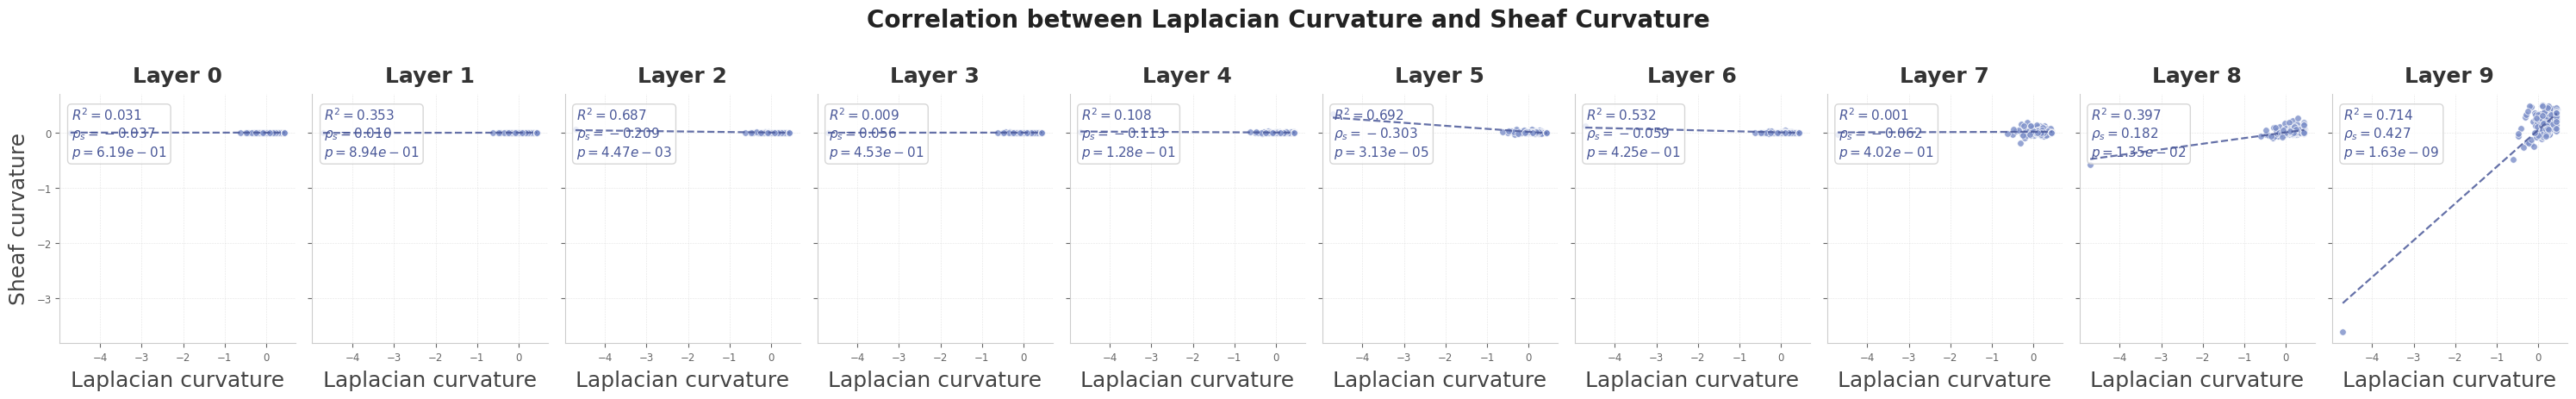

In [127]:
# plot the scatter plots between f0 and f0_top for all layers
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line

degrees = f0_top

for layer in range(layers):
    ax = axes[layer]
    #ax = axes
    y  = f0_list[layer]

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4)

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with both metrics
    stats_text = f"$R^2 = {r2:.3f}$\n$\\rho_s = {spearman_r:.3f}$\n$p = {spearman_p:.2e}$"
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=11,
            color=line_color,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Laplacian curvature", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Sheaf curvature", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Laplacian Curvature and Sheaf Curvature",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

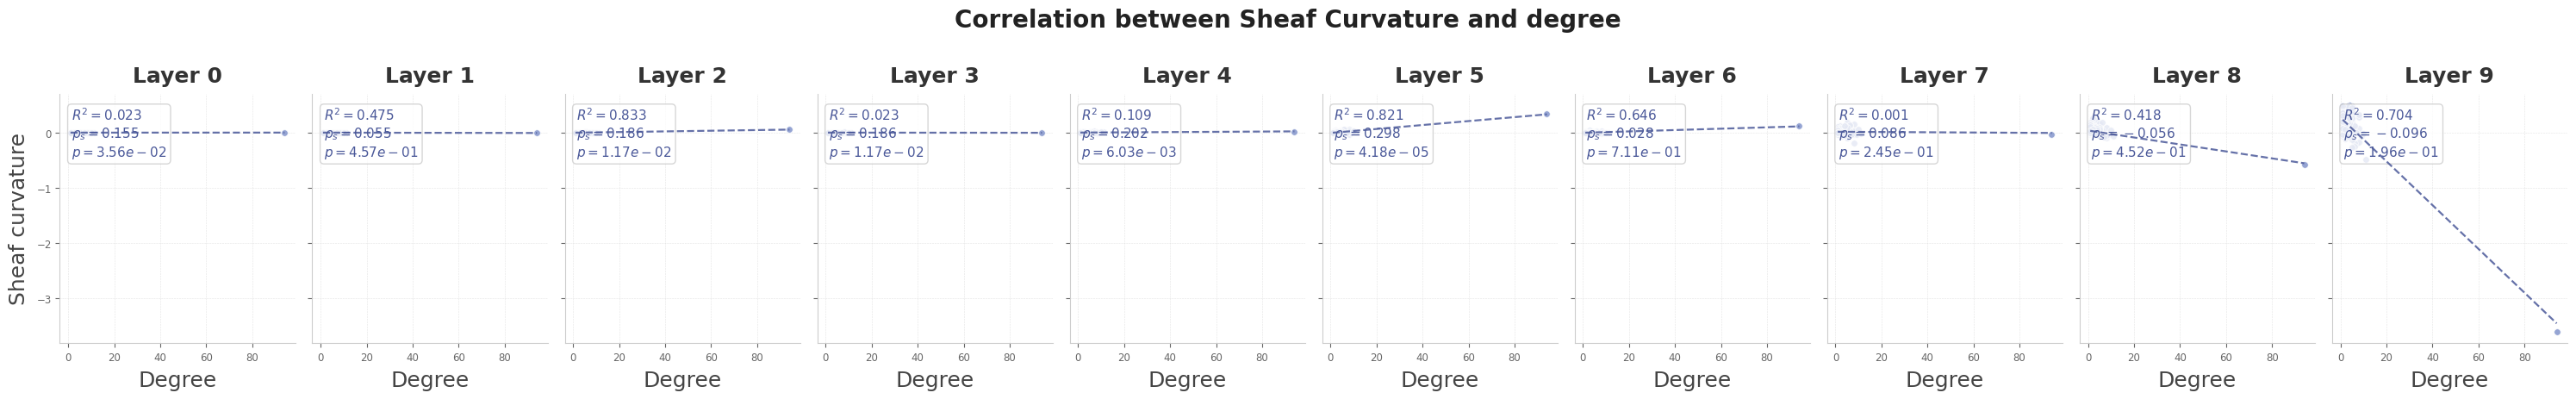

In [128]:
# plot the scatter plots between f0 and f0_top for all layers
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line

degrees = [len(G.edges(node)) for node in G.nodes()]

for layer in range(layers):
    ax = axes[layer]
    #ax = axes
    y  = f0_list[layer]

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4)

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with both metrics
    stats_text = f"$R^2 = {r2:.3f}$\n$\\rho_s = {spearman_r:.3f}$\n$p = {spearman_p:.2e}$"
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=11,
            color=line_color,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Degree", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Sheaf curvature", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Sheaf Curvature and degree",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

In [129]:
with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

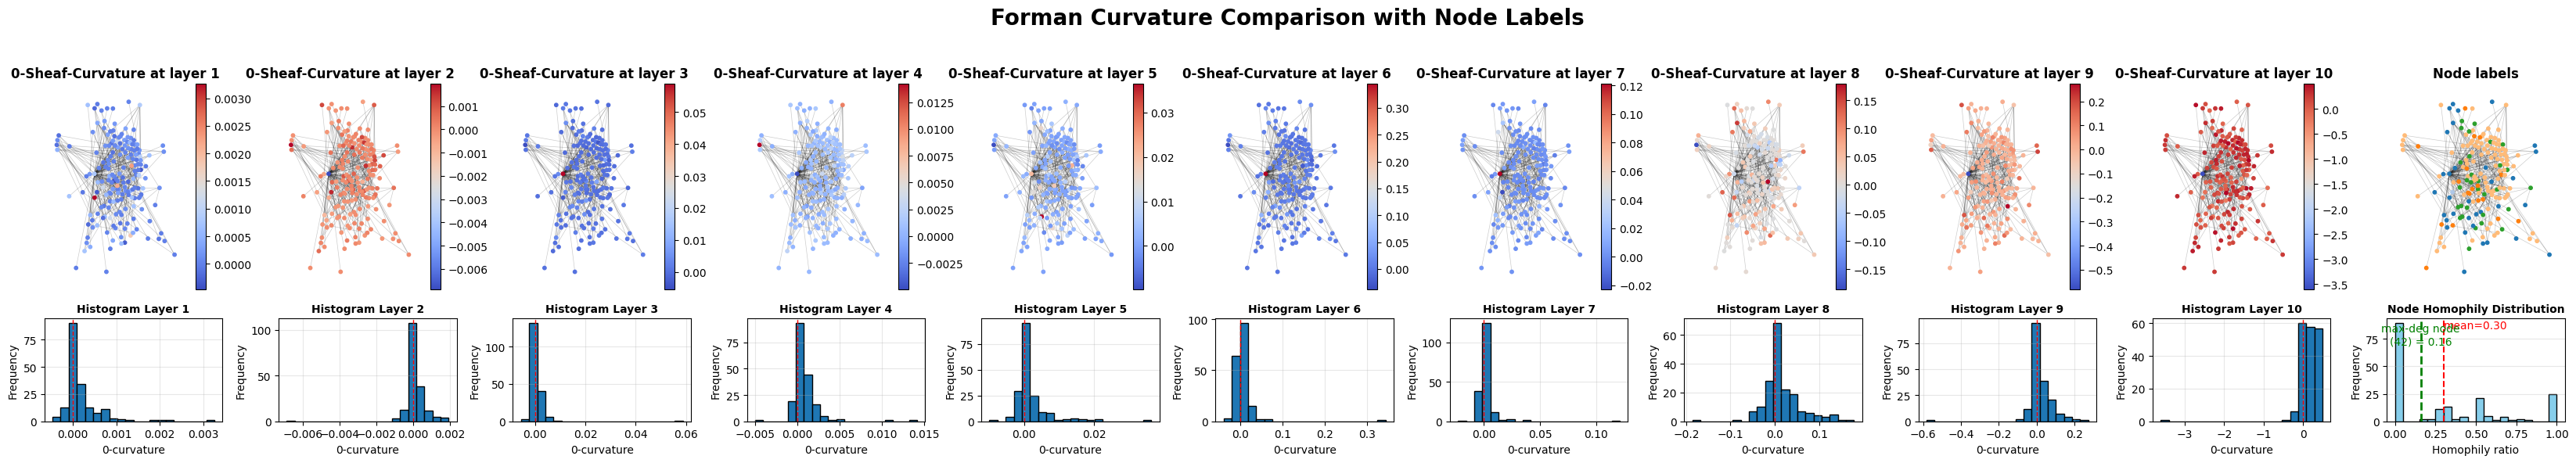

In [130]:
from tkinter import font

lab = df_node_feature["label"].values
# display(lab)

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3*(layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    curvatures = np.asarray(f0_list[layer])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(curvatures)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"0-Sheaf-Curvature at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("0-curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Forman Curvature Comparison with Node Labels", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf")
#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

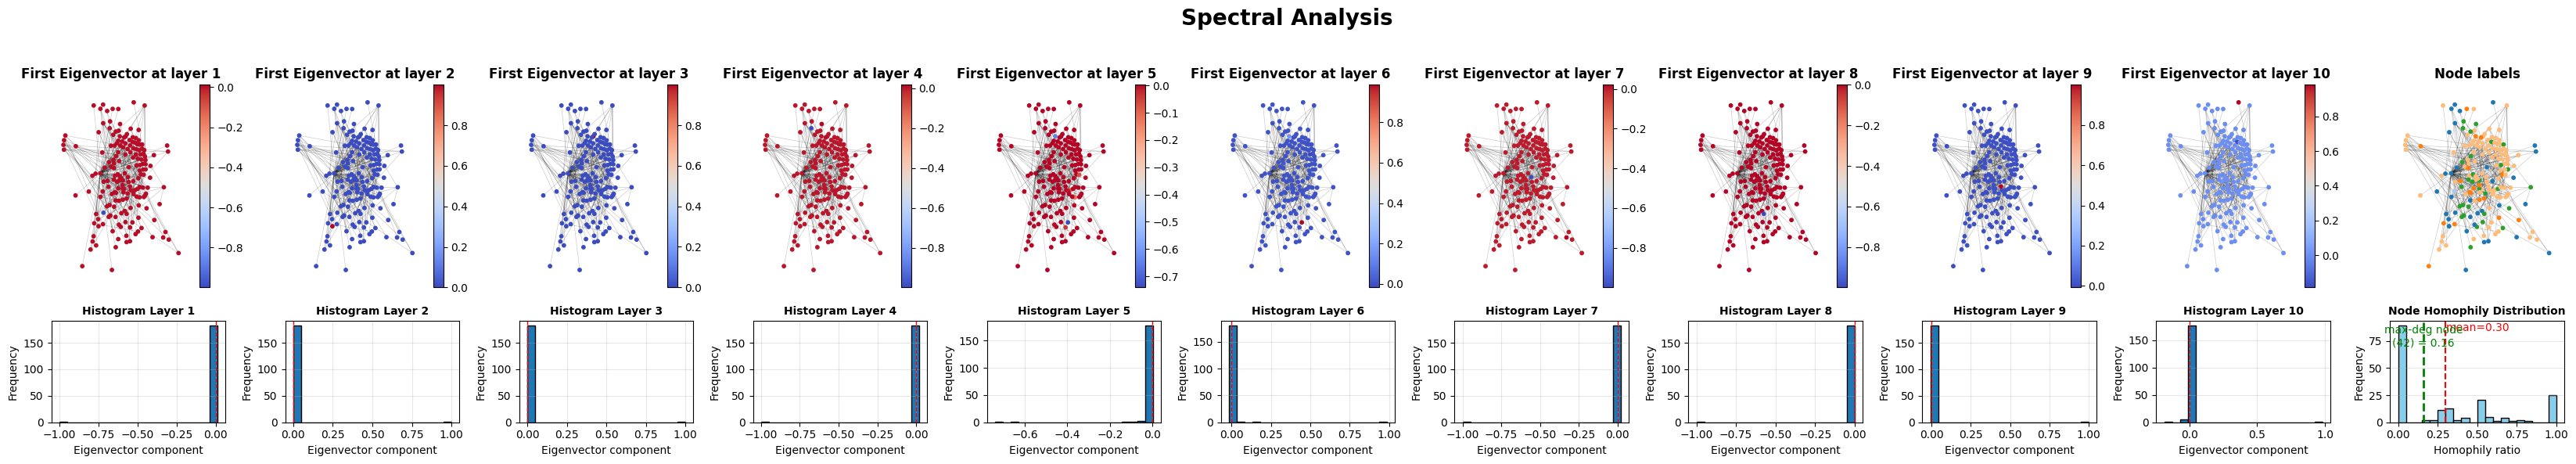

In [135]:
fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    eig00 = np.asarray(ev0_list[layer][:,0])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=eig00.min(), vmax=eig00.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(eig00)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"First Eigenvector at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(eig00, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("Eigenvector component")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)

# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Spectral Analysis", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)